In [371]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import wandb

## Carga y exploración del dataset

In [372]:
df = pd.read_csv("food_price_inflation.csv", parse_dates=["TIME_PERIOD"])
df = df.rename(columns={
    "REF_AREA": "country",
    "REF_AREA_LABEL": "country_name",
    "TIME_PERIOD": "date",
    "OBS_VALUE": "inflation"
})
df = df.sort_values(["country", "date"]).reset_index(drop=True)
df.head(10)

,country,country_name,date,inflation
0,ABW,Aruba,2001-01-01,4.287808
1,ABW,Aruba,2001-02-01,4.425079
2,ABW,Aruba,2001-03-01,4.030159
3,ABW,Aruba,2001-04-01,4.056972
4,ABW,Aruba,2001-05-01,3.753138
5,ABW,Aruba,2001-06-01,4.196718
6,ABW,Aruba,2001-07-01,3.672698
7,ABW,Aruba,2001-08-01,3.873451
8,ABW,Aruba,2001-09-01,3.870990
9,ABW,Aruba,2001-10-01,4.073828


In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59839 entries, 0 to 59838
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   country       59839 non-null  object        
 1   country_name  59839 non-null  object        
 2   date          59839 non-null  datetime64[ns]
 3   inflation     59839 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1.8+ MB


In [374]:
df.describe()

,date,inflation
count,59839,59839.000000
mean,2013-02-21 08:26:29.224418816,45.477730
min,2001-01-01 00:00:00,-24.982988
25%,2007-02-01 00:00:00,1.497504
50%,2013-03-01 00:00:00,4.091723
75%,2019-04-01 00:00:00,8.585937
max,2025-06-01 00:00:00,371537.503265
std,NaN,2864.567081


In [375]:
print(f"Países únicos:        {df['country'].nunique()}")
print(f"Rango de fechas:      {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total observaciones:  {len(df)}")

Países únicos:        206
Rango de fechas:      2001-01-01 → 2025-06-01
Total observaciones:  59839


## Visualización histórica para un país de ejemplo

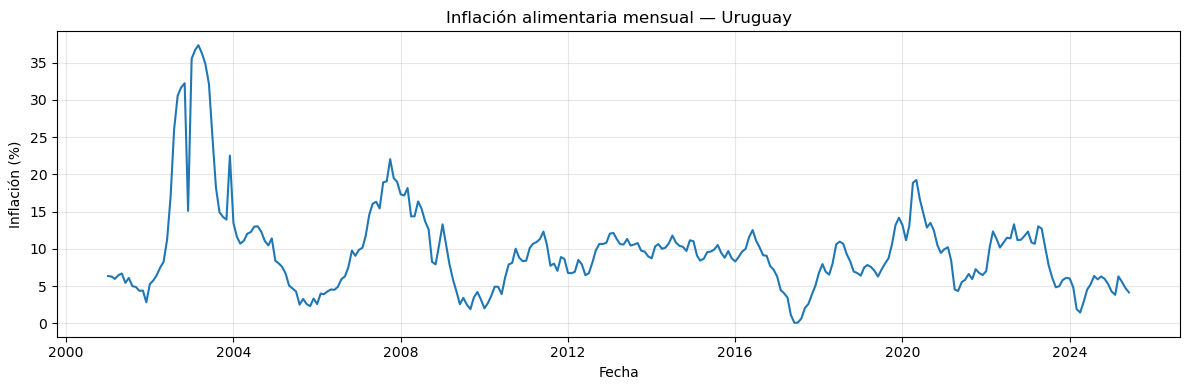

In [376]:
COUNTRY = "URY"

pais = df[df["country"] == COUNTRY].sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(pais["date"], pais["inflation"], linewidth=1.5)
plt.title(f"Inflación alimentaria mensual — {pais['country_name'].iloc[0]}")
plt.xlabel("Fecha")
plt.ylabel("Inflación (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Creación de features

El modelo recibe el par **(país, fecha)** más features temporales y predice la inflación de ese mes.

Features base:
- `country_enc` — país codificado numéricamente
- `year`, `month` — componentes temporales

Features de lag (valores históricos reales):
- `inflation_lag1/2/3/6/12` — inflación de meses anteriores
- `rolling_mean_3/12` — media móvil de los últimos 3 y 12 meses
- `yoy_change` — cambio interanual

Target: `inflation_log = log1p(clip(inflation, 0))` para reducir el impacto de outliers extremos.

In [377]:
le = LabelEncoder()
df["country_enc"] = le.fit_transform(df["country"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

# Lag features por país
for lag in [1, 2, 3, 6, 12]:
    df[f"inflation_lag{lag}"] = df.groupby("country")["inflation"].shift(lag)

# Rolling stats (shift(1) para no filtrar el valor actual)
df["rolling_mean_3"]  = df.groupby("country")["inflation"].transform(lambda x: x.shift(1).rolling(3).mean())
df["rolling_mean_12"] = df.groupby("country")["inflation"].transform(lambda x: x.shift(1).rolling(12).mean())
df["yoy_change"]      = df["inflation"] - df.groupby("country")["inflation"].shift(12)

# Log transform del target (clip para manejar valores negativos)
df["inflation_log"] = np.log1p(df["inflation"].clip(lower=0))

df = df.dropna().reset_index(drop=True)

FEATURE_COLS = [
    "country_enc", "year", "month",
    "inflation_lag1", "inflation_lag2", "inflation_lag3",
    "inflation_lag6", "inflation_lag12",
    "rolling_mean_3", "rolling_mean_12", "yoy_change"
]

print(f"Filas después de dropna: {len(df)}")
df[["country", "date", "inflation", "inflation_log"] + FEATURE_COLS].head()

Filas después de dropna: 57367


,country,date,inflation,inflation_log,country_enc,year,month,inflation_lag1,inflation_lag2,inflation_lag3,inflation_lag6,inflation_lag12,rolling_mean_3,rolling_mean_12,yoy_change
0,ABW,2002-01-01,4.087677,1.626821,0,2002,1,4.539627,4.446186,4.073828,3.672698,4.287808,4.353214,4.102221,-0.200131
1,ABW,2002-02-01,4.087414,1.626770,0,2002,2,4.087677,4.539627,4.446186,3.873451,4.425079,4.357830,4.085544,-0.337665
2,ABW,2002-03-01,3.857247,1.580472,0,2002,3,4.087414,4.087677,4.539627,3.870990,4.030159,4.238239,4.057405,-0.172912
3,ABW,2002-04-01,3.853137,1.579625,0,2002,4,3.857247,4.087414,4.087677,4.073828,4.056972,4.010779,4.042995,-0.203835
4,ABW,2002-05-01,4.013702,1.612175,0,2002,5,3.853137,3.857247,4.087414,4.446186,3.753138,3.932599,4.026009,0.260564


## Split temporal

Para series temporales el split debe ser **cronológico**, no aleatorio, para evitar filtrar datos futuros al entrenamiento.

- **Train**: todo antes del penúltimo año
- **Validación**: penúltimo año completo
- **Test**: último año completo (mide efectividad final del modelo)

In [378]:
max_date   = df["date"].max()
test_start = max_date - pd.DateOffset(years=1) + pd.DateOffset(months=1)
val_start  = test_start - pd.DateOffset(years=1)

df_train = df[df["date"] < val_start]
df_val   = df[(df["date"] >= val_start) & (df["date"] < test_start)]
df_test  = df[df["date"] >= test_start]

print(f"Train:      {df_train['date'].min().date()} → {df_train['date'].max().date()}  ({len(df_train)} obs)")
print(f"Validación: {df_val['date'].min().date()} → {df_val['date'].max().date()}  ({len(df_val)} obs)")
print(f"Test:       {df_test['date'].min().date()} → {df_test['date'].max().date()}  ({len(df_test)} obs)")

Train:      2002-01-01 → 2023-06-01  (52767 obs)
Validación: 2023-07-01 → 2024-06-01  (2400 obs)
Test:       2024-07-01 → 2025-06-01  (2200 obs)


In [379]:
wandb.init(
    project="food-inflation-forecasting",
    name="random-forest-v1",
    config={
        "n_estimators":      200,
        "max_depth":         10,
        "min_samples_split": 2,
        "min_samples_leaf":  5,
        "max_features":      "sqrt",
        "max_samples":       None,
        "bootstrap":         True,
        "oob_score":         True,
        "criterion":         "squared_error",
        "random_state":      42,
        "features":          FEATURE_COLS,
        "train_end":         str(val_start.date()),
        "val_end":           str(test_start.date()),
    }
)

In [380]:
X_train = df_train[FEATURE_COLS].values;  y_train = df_train["inflation_log"].values
X_val   = df_val[FEATURE_COLS].values;     y_val   = df_val["inflation_log"].values
X_test  = df_test[FEATURE_COLS].values;    y_test  = df_test["inflation_log"].values

model = RandomForestRegressor(
    n_estimators=wandb.config.n_estimators,
    max_depth=wandb.config.max_depth,
    min_samples_split=wandb.config.min_samples_split,
    min_samples_leaf=wandb.config.min_samples_leaf,
    max_features=wandb.config.max_features,
    max_samples=wandb.config.max_samples,
    bootstrap=wandb.config.bootstrap,
    oob_score=wandb.config.oob_score,
    criterion=wandb.config.criterion,
    random_state=wandb.config.random_state,
    n_jobs=-1
)
model.fit(X_train, y_train)

def tolerance_accuracy(y_true, y_pred, tol):
    return np.mean(np.abs(y_pred - y_true) <= tol)

# Métricas en validación (escala original)
y_val_orig   = np.expm1(y_val)
preds_val    = np.expm1(model.predict(X_val))
mae_val  = mean_absolute_error(y_val_orig, preds_val)
rmse_val = np.sqrt(mean_squared_error(y_val_orig, preds_val))
r2_val   = r2_score(y_val_orig, preds_val)
acc1_val = tolerance_accuracy(y_val_orig, preds_val, 1)
acc2_val = tolerance_accuracy(y_val_orig, preds_val, 2)
acc5_val = tolerance_accuracy(y_val_orig, preds_val, 5)

print("--- Validación ---")
print(f"MAE:                   {mae_val:.4f}")
print(f"RMSE:                  {rmse_val:.4f}")
print(f"R²:                    {r2_val:.4f}")
print(f"Accuracy (±1pp):       {acc1_val:.4f}")
print(f"Accuracy (±2pp):       {acc2_val:.4f}")
print(f"Accuracy (±5pp):       {acc5_val:.4f}")
if wandb.config.oob_score:
    print(f"OOB Score (log):       {model.oob_score_:.4f}")

wandb.log({
    "val/mae":     mae_val,
    "val/rmse":    rmse_val,
    "val/r2":      r2_val,
    "val/acc_1pp": acc1_val,
    "val/acc_2pp": acc2_val,
    "val/acc_5pp": acc5_val,
    **({
        "val/oob_score": model.oob_score_
    } if wandb.config.oob_score else {}),
})

# Métricas en test (escala original)
y_test_orig  = np.expm1(y_test)
preds_test   = np.expm1(model.predict(X_test))
mae  = mean_absolute_error(y_test_orig, preds_test)
rmse = np.sqrt(mean_squared_error(y_test_orig, preds_test))
r2   = r2_score(y_test_orig, preds_test)
acc1 = tolerance_accuracy(y_test_orig, preds_test, 1)
acc2 = tolerance_accuracy(y_test_orig, preds_test, 2)
acc5 = tolerance_accuracy(y_test_orig, preds_test, 5)

print("\n--- Test (último año) ---")
print(f"MAE:                   {mae:.4f}")
print(f"RMSE:                  {rmse:.4f}")
print(f"R²:                    {r2:.4f}")
print(f"Accuracy (±1pp):       {acc1:.4f}")
print(f"Accuracy (±2pp):       {acc2:.4f}")
print(f"Accuracy (±5pp):       {acc5:.4f}")

wandb.log({
    "test/mae":     mae,
    "test/rmse":    rmse,
    "test/r2":      r2,
    "test/acc_1pp": acc1,
    "test/acc_2pp": acc2,
    "test/acc_5pp": acc5,
})

--- Validación ---
MAE:                   1.9581
RMSE:                  8.2557
R²:                    0.9353
Accuracy (±1pp):       0.6700
Accuracy (±2pp):       0.8425
Accuracy (±5pp):       0.9508
OOB Score (log):       0.9459

--- Test (último año) ---
MAE:                   1.4110
RMSE:                  5.4177
R²:                    0.9140
Accuracy (±1pp):       0.7350
Accuracy (±2pp):       0.8891
Accuracy (±5pp):       0.9577


## Visualización: predicciones vs reales

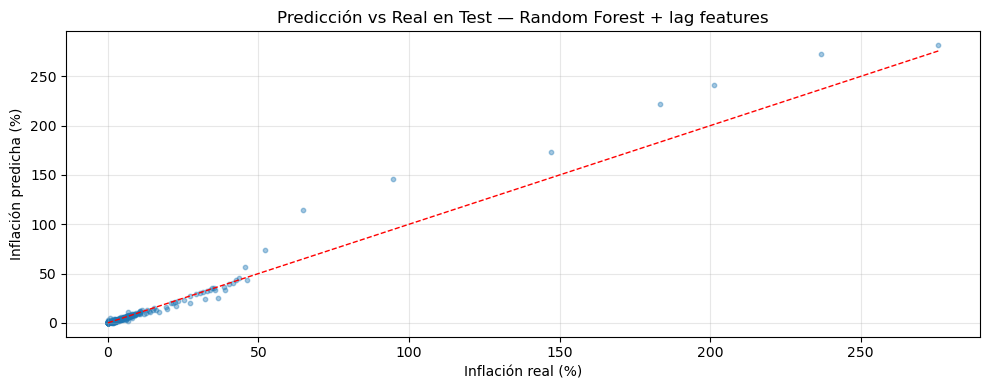

In [381]:
plt.figure(figsize=(10, 4))
plt.scatter(y_test_orig[:300], preds_test[:300], alpha=0.4, s=10)
lim = [y_test_orig[:300].min(), y_test_orig[:300].max()]
plt.plot(lim, lim, "r--", linewidth=1)
plt.xlabel("Inflación real (%)")
plt.ylabel("Inflación predicha (%)")
plt.title("Predicción vs Real en Test — Random Forest + lag features")
plt.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"charts/pred_vs_real": wandb.Image(plt)})
plt.show()

## Uruguay prediccion vs real

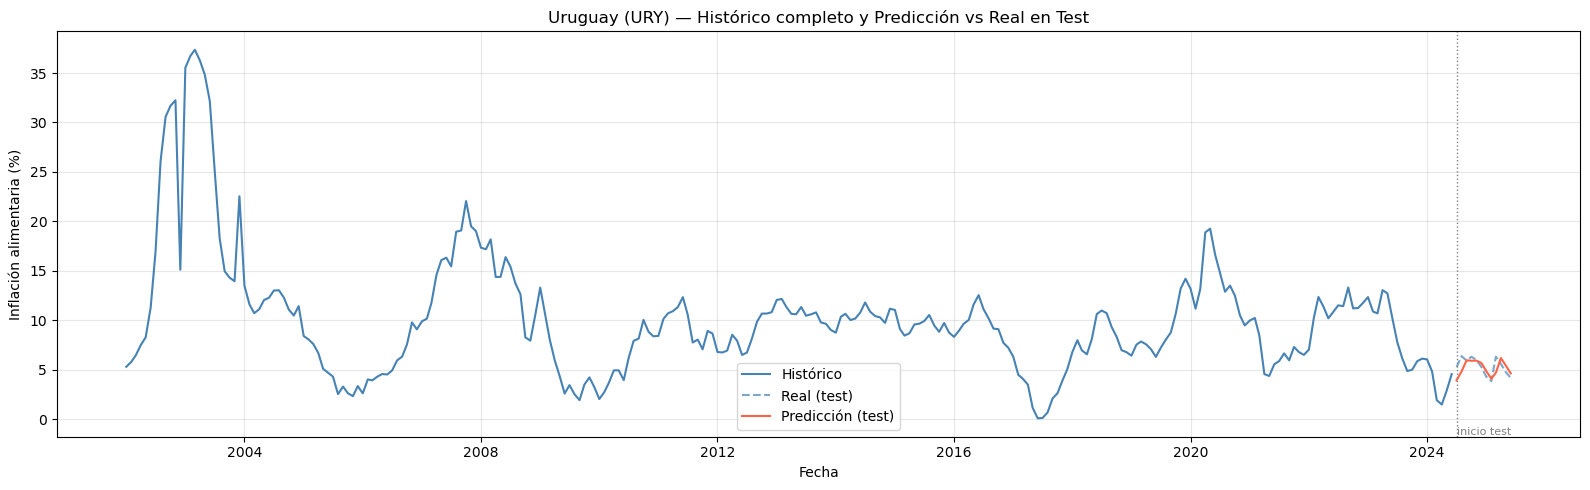

In [382]:
COUNTRY = "URY"
nombre  = df[df["country"] == COUNTRY]["country_name"].iloc[0]

# Todo el histórico disponible antes del test
historico = df[(df["country"] == COUNTRY) & (df["date"] < test_start)].sort_values("date")

# Test: real vs predicho para Uruguay
df_test_ury = df_test[df_test["country"] == COUNTRY].sort_values("date")
X_test_ury  = df_test_ury[FEATURE_COLS].values
preds_ury   = np.expm1(model.predict(X_test_ury))

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(historico["date"], historico["inflation"],
        label="Histórico", color="steelblue", linewidth=1.5)
ax.plot(df_test_ury["date"], df_test_ury["inflation"],
        label="Real (test)", color="steelblue", linewidth=1.5, linestyle="--", alpha=0.7)
ax.plot(df_test_ury["date"], preds_ury,
        label="Predicción (test)", color="tomato", linewidth=1.5)

ax.axvline(test_start, color="gray", linestyle=":", linewidth=1)
ax.text(test_start + pd.DateOffset(days=5), ax.get_ylim()[0], "inicio test",
        color="gray", fontsize=8, va="bottom")

ax.set_title(f"{nombre} ({COUNTRY}) — Histórico completo y Predicción vs Real en Test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Inflación alimentaria (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"charts/uruguay_pred_vs_real": wandb.Image(plt)})
plt.show()

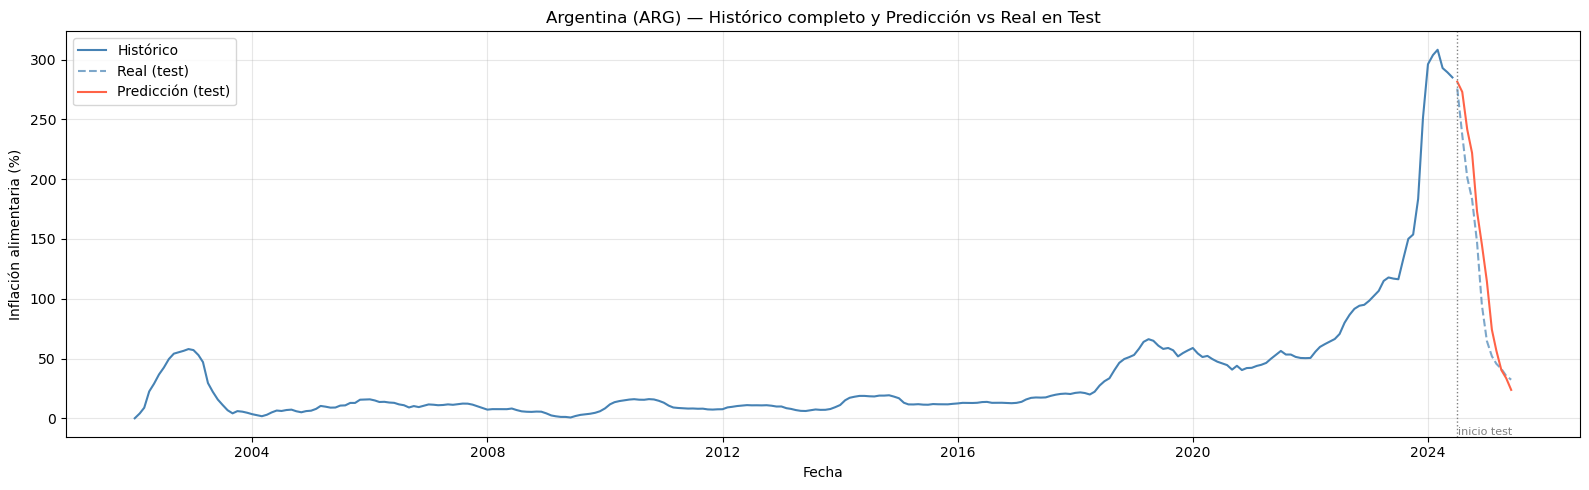

In [383]:
COUNTRY = "ARG"
nombre  = df[df["country"] == COUNTRY]["country_name"].iloc[0]

historico = df[(df["country"] == COUNTRY) & (df["date"] < test_start)].sort_values("date")

df_test_arg = df_test[df_test["country"] == COUNTRY].sort_values("date")
X_test_arg  = df_test_arg[FEATURE_COLS].values
preds_arg   = np.expm1(model.predict(X_test_arg))

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(historico["date"], historico["inflation"],
        label="Histórico", color="steelblue", linewidth=1.5)
ax.plot(df_test_arg["date"], df_test_arg["inflation"],
        label="Real (test)", color="steelblue", linewidth=1.5, linestyle="--", alpha=0.7)
ax.plot(df_test_arg["date"], preds_arg,
        label="Predicción (test)", color="tomato", linewidth=1.5)

ax.axvline(test_start, color="gray", linestyle=":", linewidth=1)
ax.text(test_start + pd.DateOffset(days=5), ax.get_ylim()[0], "inicio test",
        color="gray", fontsize=8, va="bottom")

ax.set_title(f"{nombre} ({COUNTRY}) — Histórico completo y Predicción vs Real en Test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Inflación alimentaria (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"charts/argentina_pred_vs_real": wandb.Image(plt)})
plt.show()

## Predicción: próximos 12 meses para un país

Dado un país, generamos predicciones mes a mes para el año siguiente al último dato disponible.

In [384]:
def predict_next_12_months(country_code: str, model, le, df) -> pd.DataFrame:
    if country_code not in le.classes_:
        raise ValueError(f"País '{country_code}' no está en el dataset")

    country_enc  = le.transform([country_code])[0]
    country_df   = df[df["country"] == country_code].sort_values("date")
    last_date    = country_df["date"].max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

    # Historial reciente para construir lags de forma recursiva
    recent = list(country_df["inflation"].tail(12).values)

    rows = []
    for date in future_dates:
        n = len(recent)
        lag1  = recent[-1]  if n >= 1  else 0
        lag2  = recent[-2]  if n >= 2  else 0
        lag3  = recent[-3]  if n >= 3  else 0
        lag6  = recent[-6]  if n >= 6  else 0
        lag12 = recent[-12] if n >= 12 else 0
        rm3   = np.mean(recent[-3:])  if n >= 3  else np.mean(recent)
        rm12  = np.mean(recent[-12:]) if n >= 12 else np.mean(recent)
        yoy   = recent[-1] - recent[-12] if n >= 12 else 0

        X = np.array([[country_enc, date.year, date.month,
                       lag1, lag2, lag3, lag6, lag12, rm3, rm12, yoy]])
        pred = float(np.expm1(model.predict(X)[0]))
        rows.append({"date": date, "inflation_pred": round(pred, 2)})

        # Agregar predicción al historial para el próximo paso (recursivo)
        recent.append(pred)

    return pd.DataFrame(rows)

In [385]:
COUNTRY = "URY"

forecast = predict_next_12_months(COUNTRY, model, le, df)
print(f"Predicciones para {COUNTRY} — próximos 12 meses:")
print(forecast.to_string(index=False))

Predicciones para URY — próximos 12 meses:
      date  inflation_pred
2025-07-01            4.12
2025-08-01            3.86
2025-09-01            3.59
2025-10-01            3.27
2025-11-01            3.05
2025-12-01            2.88
2026-01-01            2.71
2026-02-01            2.59
2026-03-01            2.23
2026-04-01            1.91
2026-05-01            1.67
2026-06-01            1.50


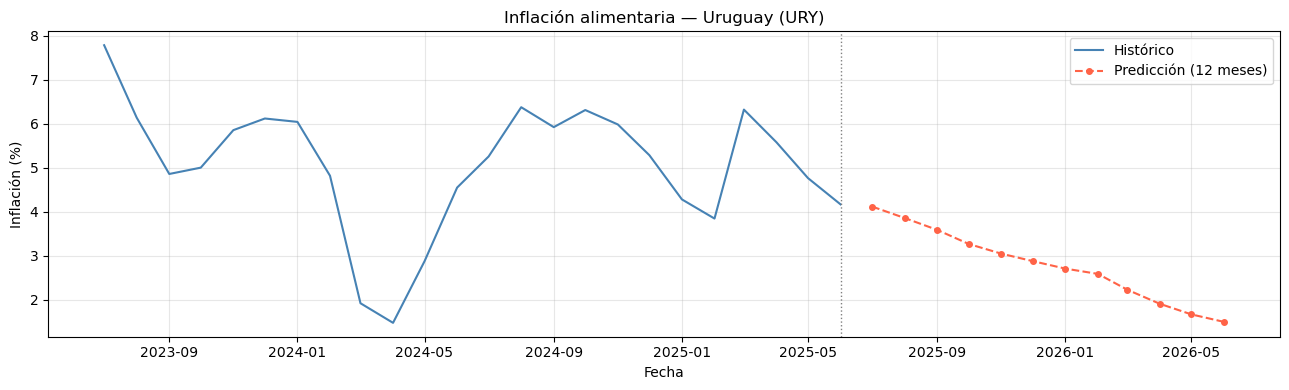

In [386]:
# Datos históricos del país para contexto
historico = df[df["country"] == COUNTRY].sort_values("date").tail(24)
nombre = df[df["country"] == COUNTRY]["country_name"].iloc[0]

plt.figure(figsize=(13, 4))
plt.plot(historico["date"], historico["inflation"], label="Histórico", linewidth=1.5, color="steelblue")
plt.plot(forecast["date"], forecast["inflation_pred"], label="Predicción (12 meses)",
         linewidth=1.5, linestyle="--", color="tomato", marker="o", markersize=4)
plt.axvline(historico["date"].iloc[-1], color="gray", linestyle=":", linewidth=1)
plt.title(f"Inflación alimentaria — {nombre} ({COUNTRY})")
plt.xlabel("Fecha")
plt.ylabel("Inflación (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"charts/forecast_ury": wandb.Image(plt)})
plt.show()

In [387]:
# Comparar varios países
for code in ["ARG", "BRA", "URY", "USA"]:
    f = predict_next_12_months(code, model, le, df)
    nombre = df[df["country"] == code]["country_name"].iloc[0]
    print(f"\n{nombre} ({code}):")
    print(f"  Min: {f['inflation_pred'].min():.2f}%  |  Max: {f['inflation_pred'].max():.2f}%  |  Promedio: {f['inflation_pred'].mean():.2f}%")


Argentina (ARG):
  Min: 0.34%  |  Max: 20.71%  |  Promedio: 4.08%

Brazil (BRA):
  Min: 4.87%  |  Max: 6.72%  |  Promedio: 5.89%

Uruguay (URY):
  Min: 1.50%  |  Max: 4.12%  |  Promedio: 2.78%

United States (USA):
  Min: 2.61%  |  Max: 2.83%  |  Promedio: 2.75%


## Guardar modelo y métricas

In [388]:
joblib.dump({"model": model, "label_encoder": le, "features": FEATURE_COLS}, "model.pkl")

metrics = {"mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4)}
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Modelo guardado en model.pkl")
print("Métricas guardadas en metrics.json")

# W&B: registrar modelo como artifact versionado
artifact = wandb.Artifact(
    name="food-inflation-model",
    type="model",
    description="RandomForest para predicción de inflación alimentaria",
    metadata={"mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4)}
)
artifact.add_file("model.pkl")
logged_artifact = wandb.log_artifact(artifact)

Modelo guardado en model.pkl
Métricas guardadas en metrics.json


In [389]:


# Registrar en el Model Registry y promover a staging
# wandb.run.link_artifact(logged_artifact, "model-registry/food-inflation-model", aliases=["staging"])

wandb.run.link_artifact(
    logged_artifact,
    "wandb-registry-model/food-inflation-model",
    aliases=["staging"]
)

wandb.finish()
print("Run de W&B finalizado — modelo registrado en el Model Registry como 'staging'")

test/acc_1pp,▁
test/acc_2pp,▁
test/acc_5pp,▁
test/mae,▁
test/r2,▁
test/rmse,▁
val/acc_1pp,▁
val/acc_2pp,▁
val/acc_5pp,▁
val/mae,▁
+3,...


Run de W&B finalizado — modelo registrado en el Model Registry como 'staging'
